<h1 align="center"> Statistics and Financial Data Science </h1>




GARCH examples
===

In [1]:
%reset -f

In [2]:
#import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
import math as m
import scipy as sp
from statsmodels.stats.anova import anova_lm
import pandas_datareader as pd_data

In [3]:
# Importing the Time Series Analysis module for simulating data
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARMAResults
from statsmodels.tsa.stattools import arma_order_select_ic
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.tsa.stattools as sm_tools

In [4]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import pmdarima as pm 
from datetime import datetime
# For splines
import patsy
from patsy import dmatrix
from arch import arch_model
from arch.univariate import ARX
from arch.univariate import GARCH
import pandas_datareader.data as web
import datetime as dt
import scipy.stats as st

In [5]:
# Will fix figure size for this notebook
plt.rcParams["figure.figsize"] = (8,6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:

def plot_diagnosticsTight3(data):

    fig, ((ax1,ax2),(ax3,ax4), (ax5,ax6)) = plt.subplots(3,2,figsize=(10,10))
    
    ax1.hist(data, bins =40,color='m', density = True)  
    mu = data.mean()
    sigma = data.std()
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 2419)
    ax1.plot(x, stats.norm.pdf(x, mu, sigma), linewidth= 5)
    ax1.grid()
    ax1.set_title("Hist Data")
    
    ax2.plot(data)
    ax2.grid()
    ax2.set_title("Data")
    
    fig = plot_acf(data,lags=40,zero=False, ax = ax3,use_vlines = True)
    ax3.grid()
    
    #logData = np.floor(np.log(len(data)))
    ljbox_test = sm.stats.acorr_ljungbox(data,10)#package version
    
    ax4.plot(ljbox_test['lb_pvalue'])
    ax4.axhline(y=0.05, color='r',ls='--')
    ax4.set_title("LB test")
    ax4.grid()
    
    fig = sm.qqplot(data, line='q', ax = ax5)
    ax5.grid()
    
    ax6.plot(data*data)
    ax6.grid()
    ax6.set_title("Data Sqr")
    
    plt.tight_layout()

In [7]:
start = dt.datetime(2007,1,1)
end = dt.datetime(2019,11,26)
AAPL = web.get_data_yahoo('AAPL', start=start, end=end)
AAPL.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2019-11-20,66.519997,65.099998,66.385002,65.797501,106234400.0,64.460342
2019-11-21,66.002502,65.294998,65.922501,65.502502,121395200.0,64.171333
2019-11-22,65.794998,65.209999,65.647499,65.445000,65325200.0,64.114983
2019-11-25,66.610001,65.629997,65.677498,66.592499,84020400.0,65.239182
2019-11-26,66.790001,65.625000,66.735001,66.072502,105207600.0,64.729744


In [8]:
# Let's look at the returns
AAPLRet = np.log(AAPL['Adj Close']).diff().dropna()
AAPLRet.head()

Date
2007-01-04    0.021953
2007-01-05   -0.007146
2007-01-08    0.004926
2007-01-09    0.079800
2007-01-10    0.046746
Name: Adj Close, dtype: float64

1) Plot ACF/PACF for first impression on autoregressive features

2) Test for stationarity (otherwise transform)

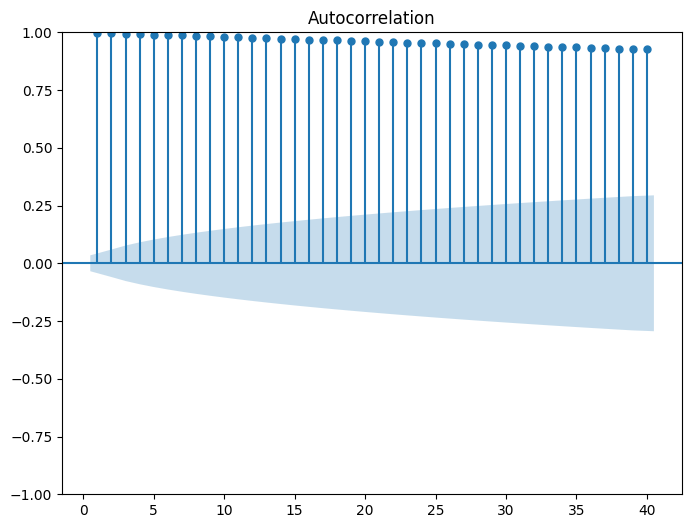

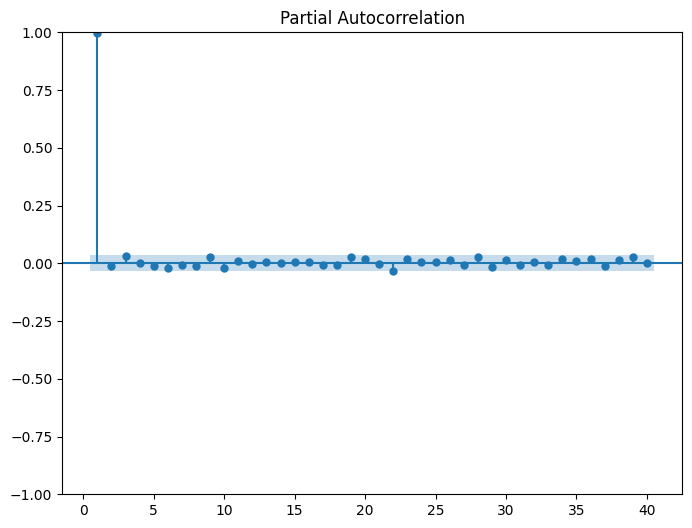

In [9]:
plot_acf(AAPL['Adj Close'],zero = False, lags = 40);
plot_pacf(AAPL['Adj Close'], zero = False, lags =40);
plt.show()

Data passes the stationarity tests - I can consider modelling as an ARMA process
===

In [10]:
# Reject Unit Root
test = adfuller(AAPLRet, maxlag = 5)
print('ADF Statistic: %f' % test[0])
print('p-value: %f' % test[1])
print('Critical Values:i/')
for item, value in test[4].items():
    print('\t%s: %.2f' % (item, value))

ADF Statistic: -27.638171
p-value: 0.000000
Critical Values:i/
	1%: -3.43
	5%: -2.86
	10%: -2.57


In [11]:
# Kpss test supports stationarity
num = len(AAPLRet)
maxLag = np.log(num)
test = kpss(AAPLRet, nlags = int(maxLag)) 
print('KPSS Statistic: %f' % test[0])
print('p-value: %f' % test[1])
print('Critical Values:')
for item, value in test[3].items():
    print('\t%s: %.2f' % (item, value))

KPSS Statistic: 0.059144
p-value: 0.100000
Critical Values:
	10%: 0.35
	5%: 0.46
	2.5%: 0.57
	1%: 0.74


3) Find / fit best ARMA model (already differenced once).

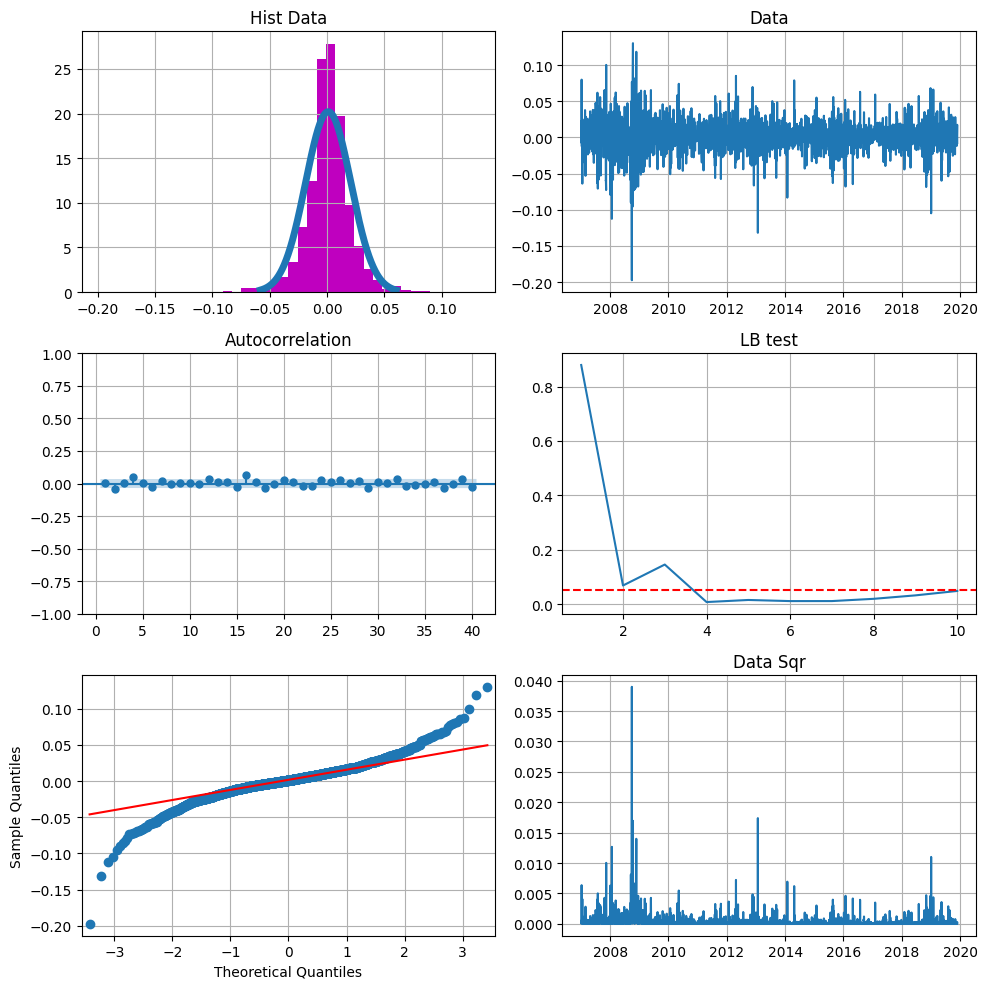

In [12]:
# Just plotting graphs on the actual data and examining the results fo the Ljung-Box test...
# I see that there is auto-correlation

plot_diagnosticsTight3(AAPLRet)

In [13]:
# So can fit an ARMA type model
results = pm.auto_arima(AAPLRet, trace = True, seasonal=False, stationary = True, stepwise = False,with_intercept=True, information_criterion='aic', start_q=0, max_p = 6, max_q = 1,d=0) 
# Order selected is given in summary
print(results.summary())
# This chooses AR 2 model for the mean

 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-16273.410, Time=0.25 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-16271.434, Time=0.29 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-16271.432, Time=0.21 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-16269.801, Time=0.43 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-16274.785, Time=0.29 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-16272.744, Time=0.29 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-16272.807, Time=0.53 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-16270.806, Time=0.36 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=-16278.970, Time=0.64 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=-16276.967, Time=1.28 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=-16277.058, Time=1.06 sec

Best model:  ARIMA(4,0,0)(0,0,0)[0] intercept
Total fit time: 5.634 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3248
Model:           

In [14]:
?pm.auto_arima

In [15]:
model = sm.tsa.SARIMAX(AAPLRet, order=(4, 0, 0))
fit = model.fit(disp = False)
print(fit.summary());

                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 3248
Model:               SARIMAX(4, 0, 0)   Log Likelihood                8141.511
Date:                Mon, 21 Nov 2022   AIC                         -16273.022
Time:                        12:19:09   BIC                         -16242.593
Sample:                             0   HQIC                        -16262.121
                               - 3248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0051      0.011      0.468      0.640      -0.016       0.026
ar.L2         -0.0357      0.012     -2.917      0.004      -0.060      -0.012
ar.L3          0.0036      0.011      0.320      0.7

4) Plot Diagnostics on residuals of the model

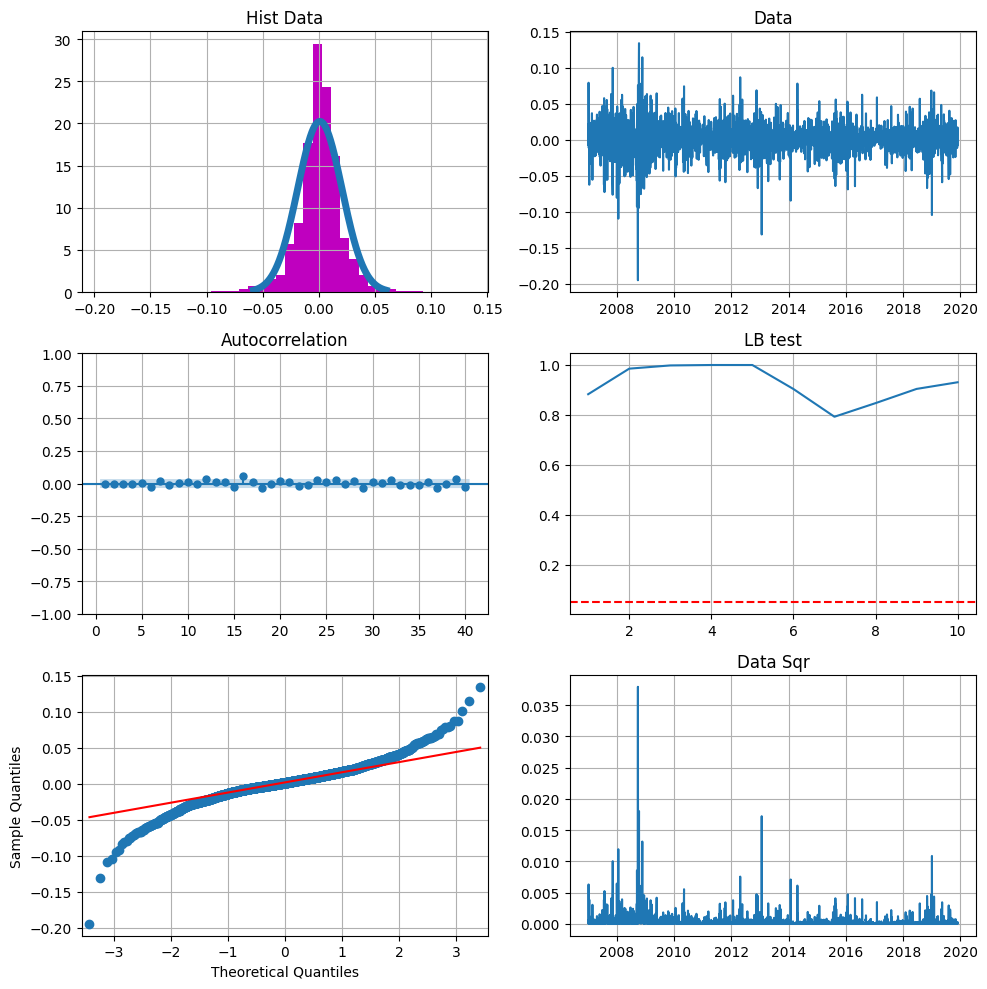

In [16]:
plot_diagnosticsTight3(fit.resid)

Even though there is no auto-correlation and residuals pass the Ljung-Box test, there seem to be clusters 
in the data and also the QQ plot does not fit with normality. There could be due to heteroskedasticity - so we examine
the squared residulas

5) Check squared residuals ACF/PACF - these indicate some AR with order maybe 5 - 9, depending on how complex we wish model to be.

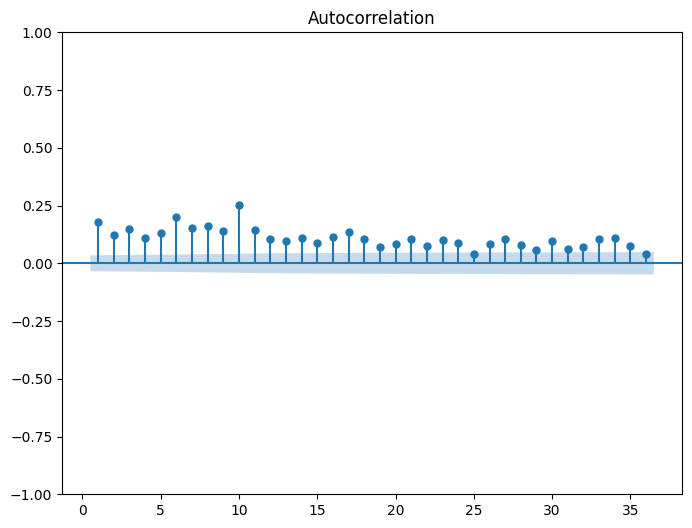

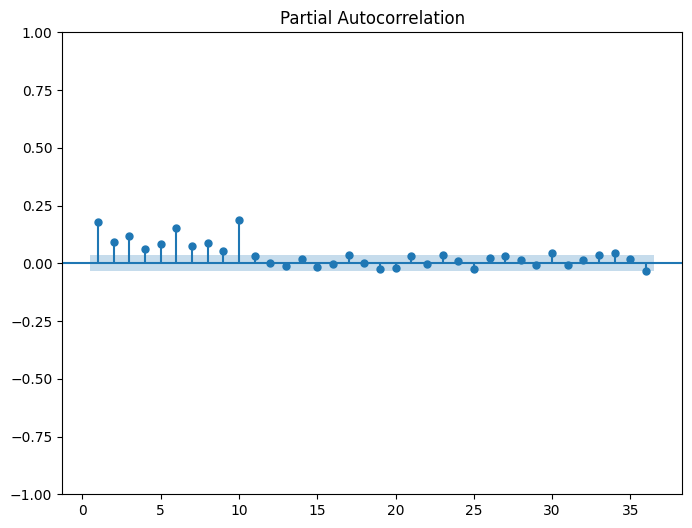

In [17]:
plot_acf(fit.resid**2, zero = False);
plot_pacf(fit.resid**2, zero = False);

plt.show()

In [18]:
# Above were examples with SARIMAX which are familiar with. In arch_model we need to
# specify a mean model using a different method - this is restricted to AR type only, with 
# potential external regressors.

6) Combine the models by specifying the mean and vol processes into a GARCH model:

In [19]:
# The model allows us to choose specific lags - this is very similar to the SARIMAX function from statsmodels:
# Diff are possibly due to numerical approx / methods/ tolerance

newAAPLRet = AAPLRet
arx = ARX(newAAPLRet, lags= 4,rescale = False) #this is eq. to AR(4) as per above
arx.volatility = GARCH(3,0,0)
res = arx.fit(update_freq=0)#, tol=0.000001
print(res.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: -8265.438433981832
            Iterations: 13
            Function evaluations: 144
            Gradient evaluations: 9
                           AR - ARCH Model Results                            
Dep. Variable:              Adj Close   R-squared:                      -0.002
Mean Model:                        AR   Adj. R-squared:                 -0.003
Vol Model:                       ARCH   Log-Likelihood:                8265.44
Distribution:                  Normal   AIC:                          -16512.9
Method:            Maximum Likelihood   BIC:                          -16458.1
                                        No. Observations:                 3244
Date:                Mon, Nov 21 2022   Df Residuals:                     3239
Time:                        12:19:10   Df Model:                            5
                                   Mean Model                                  

- I'm suspiscious on the convergence of the model as all alphas are the same. 
- We can try using the rescale function to see if we obtain an improvement or
- We can try to scale the returns (by x 100)... let's try both and watch the effect on coefficients

In [20]:
newAAPLRet =AAPLRet*100
arx = ARX(newAAPLRet, lags=2,rescale = False) #this is eq. to AR(4) as per above
arx.volatility = GARCH(3,0,0)
res = arx.fit(update_freq=0)#, tol=0.000001
print(res.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 6558.330587103719
            Iterations: 16
            Function evaluations: 147
            Gradient evaluations: 16
                           AR - ARCH Model Results                            
Dep. Variable:              Adj Close   R-squared:                      -0.003
Mean Model:                        AR   Adj. R-squared:                 -0.004
Vol Model:                       ARCH   Log-Likelihood:               -6558.33
Distribution:                  Normal   AIC:                           13130.7
Method:            Maximum Likelihood   BIC:                           13173.3
                                        No. Observations:                 3246
Date:                Mon, Nov 21 2022   Df Residuals:                     3243
Time:                        12:19:10   Df Model:                            3
                                   Mean Model                                  

7) Analyse outputs and consider diagnostics of model

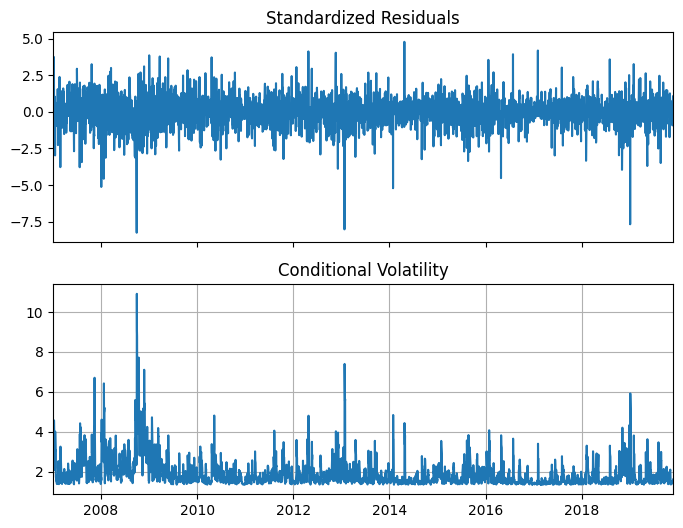

In [21]:
# Exploring the outputs
res.plot()
plt.grid()
plt.show()

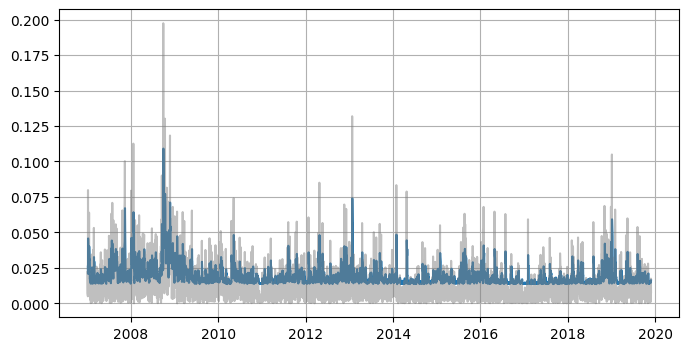

In [22]:
# Plot conditional vol vs abs(ret)
plt.figure(1, figsize=(8,4))
plt.plot(res.conditional_volatility/100)
plt.plot(abs(AAPLRet), color = 'grey', alpha = 0.5)
plt.grid()
plt.show()

7) Consider Diagnostics of StdResiduals: Ljung-Box tests to verify no autocorrelation and normality tests

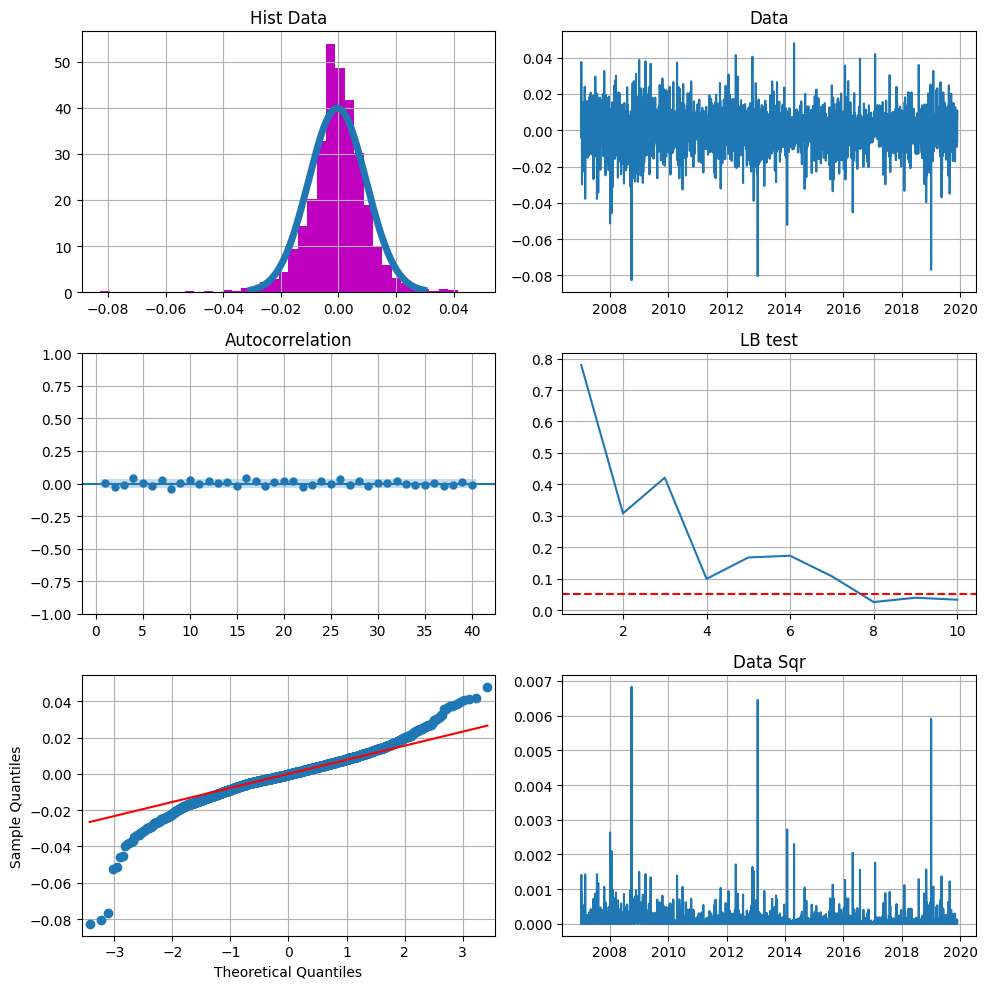

In [23]:
std_resid = res.resid/100/res.conditional_volatility
std_resid = std_resid.dropna()
plot_diagnosticsTight3(std_resid)

- The standardized residuals have passed the Ljung-Box test, supporting the case that they are white noise
- However, the QQ plot still does not seem to fit a normal, potentially a different distribution shoudl be considered.
- We should verify by formal normality tests: both reject hypothesis of normality.

In [24]:
JB_test = stats.jarque_bera(std_resid)
print('Jarque-Bera statitiscs: ', JB_test[0])
print('Jarque-Bera p-value: ', JB_test[1])

Jarque-Bera statitiscs:  4254.786193297968
Jarque-Bera p-value:  0.0


In [25]:
shap_test = stats.shapiro(std_resid)
print('Shapiro statitiscs: ', shap_test[0])
print('Shapiro p-value: ', shap_test[1])

Shapiro statitiscs:  0.9531493782997131
Shapiro p-value:  4.625067158903549e-31


Text(0.5, 1.0, 'With GARCH')

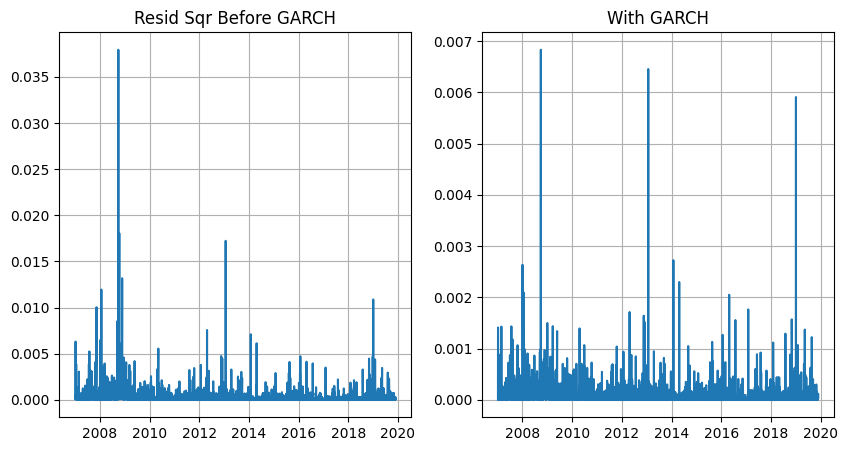

In [26]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.plot(fit.resid**2)
ax1.grid()
ax1.set_title("Resid Sqr Before GARCH")
ax2.plot(std_resid**2)
ax2.grid()
ax2.set_title("With GARCH")

8) Forecasting using the model

Here the notatios follows the convention say for GARCH(1,1) with constant mean:

$$r_t = \mu + \epsilon_t$$
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta\sigma^2_{t-1}$$
$$ \epsilon_t = \sigma_t e_t, \quad \ e_t \sim N(0,1)$$

In [27]:
forecasts = res.forecast(horizon=5)
print(forecasts.mean.iloc[-3:])

                h.1       h.2       h.3       h.4       h.5
Date                                                       
2019-11-22      NaN       NaN       NaN       NaN       NaN
2019-11-25      NaN       NaN       NaN       NaN       NaN
2019-11-26  0.16352  0.146528  0.162778  0.162951  0.163243


In [28]:
# To pick up the value of interest use -1
forecasts = res.forecast(horizon=5)
print(forecasts.mean.iloc[-1:])
print(forecasts.variance.iloc[-1:]) #Expected Variance of epsilon_t
print(forecasts.residual_variance.iloc[-1:])# Forecast variance of the process: Expected r**2_t

                h.1       h.2       h.3       h.4       h.5
Date                                                       
2019-11-26  0.16352  0.146528  0.162778  0.162951  0.163243
                 h.1       h.2       h.3       h.4       h.5
Date                                                        
2019-11-26  2.491805  3.082388  3.243818  3.611751  3.833544
                 h.1       h.2       h.3       h.4       h.5
Date                                                        
2019-11-26  2.491805  3.080276  3.240353  3.607946  3.829371


In [29]:
# Using simulation method
forecasts = res.forecast(horizon=5, method = 'simulation')
print(forecasts.mean.iloc[-1:])
print(forecasts.variance.iloc[-1:])
print(forecasts.residual_variance.iloc[-1:])

                h.1       h.2       h.3       h.4       h.5
Date                                                       
2019-11-26  0.16352  0.146528  0.162778  0.162951  0.163243
                 h.1       h.2       h.3       h.4       h.5
Date                                                        
2019-11-26  2.491805  3.121386  3.231902  3.601905  3.785161
                 h.1       h.2       h.3       h.4    h.5
Date                                                     
2019-11-26  2.491805  3.119274  3.228404  3.598096  3.781


Using Simulations in Forecast
===

In [30]:
# To illustrate example, set number of simulations to 6 and look at 3 step horizon:

forecasts = res.forecast(horizon=3, method = 'simulation',simulations = 6)  
print(forecasts.mean.iloc[-4:])
print(forecasts.variance.iloc[-4:])
print(forecasts.residual_variance.iloc[-4:])

#This will query expected values for the past 4 dates and display all horizons's expected values above.

                h.1       h.2       h.3
Date                                   
2019-11-21      NaN       NaN       NaN
2019-11-22      NaN       NaN       NaN
2019-11-25      NaN       NaN       NaN
2019-11-26  0.16352  0.146528  0.162778
                 h.1       h.2       h.3
Date                                    
2019-11-21       NaN       NaN       NaN
2019-11-22       NaN       NaN       NaN
2019-11-25       NaN       NaN       NaN
2019-11-26  2.491805  3.387193  3.548737
                 h.1       h.2       h.3
Date                                    
2019-11-21       NaN       NaN       NaN
2019-11-22       NaN       NaN       NaN
2019-11-25       NaN       NaN       NaN
2019-11-26  2.491805  3.385081  3.545013


In [31]:
# What is the shape of this variable?
print(forecasts.simulations.values.shape)

# First dimension is 3248 which is the number of points used for fitting (last observation)
# Second dimension is the number of simulations
# Third dimenstion, the number of horizons (h-steps ahead)

# Notice that as we used all points in our fitting, the forecasts return NAN for all except the last point.
# Hence we will query only forecasts.simulations.values[-1,x,y] to extract only final date forecasts.

(3248, 6, 3)


In [32]:
# By printing all values is not necessarily intuitive to see what is going on
forecasts.simulations.values

array([[[        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan]],

       [[        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan]],

       [[        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan],
        [        nan,         nan,         nan]],

       ...,

       [[        nan,         nan,         nan],
        [        nan,         nan,         nan],
 

In [33]:
# To get the value of LAST path, all 3 horizon simulations (h1,h2,h3):
forecasts.simulations.values[-1,-1,:] 

array([ 0.45480283, -2.68732299, -2.47013145])

In [34]:
# To get the value of all simulations of h3 (only) 
forecasts.simulations.values[-1,:,-3] 
# 6 simulations for 3-step ahead horizon generated.

array([-1.37136626, -1.28570802,  2.48554453,  0.84253948, -3.12858244,
        0.45480283])

In [35]:
# Change horizon to 5 and increase the number of simulations - this is exciting!
forecasts = res.forecast(horizon=5, method = 'simulation',simulations = 10)

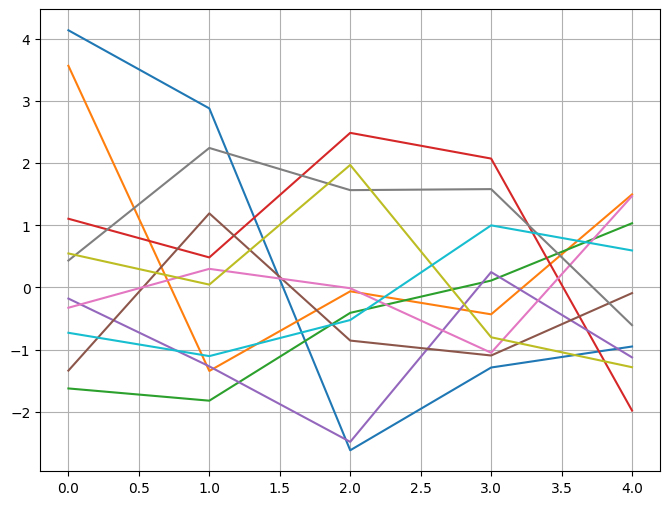

In [36]:
# To get ALL the paths, all 5 horizon simulations (h1..h5):
paths = forecasts.simulations.values[-1,:,:].T #Each path is a sequence of h1,h2,h3,h5 (and 10 paths displayed)
plt.plot(paths);
plt.grid()
plt.show()

In [37]:
# Why do I need to transpose?
forecasts.simulations.values[-1,:,:].shape 
# 10 by 5, I'm interested in the data as a 5 by 10 (5 points in the x axis for horizon, y is the value of each horizon path)

(10, 5)

In [2]:
# Let's go crazy... 100 paths, what do we see now?
forecasts = res.forecast(horizon=5, method = 'simulation',simulations = 100)
paths = forecasts.simulations.values[-1,:,:].T 
#Each path is a sequence of h1,h2,h3,h5 (and 100 paths displayed)
plt.plot(paths);
plt.grid()
plt.show()

NameError: name 'res' is not defined

NameError: name 'forecasts' is not defined

In [39]:
# To get a cross sample of all forecasts at a particular point in time, say all simulations of h-steps-ahead:
h1_values = forecasts.simulations.values[-1,:,0] 
h2_values = forecasts.simulations.values[-1,:,1] 
h3_values = forecasts.simulations.values[-1,:,2] 
h4_values = forecasts.simulations.values[-1,:,3] 
h5_values = forecasts.simulations.values[-1,:,4] 

In [40]:
# Hence, if I'm interested in the forecast of 5-day ahead, I can look at the distribution of the simulation
# to get confidence bounds around mean.
print(h5_values.mean())
print(h5_values.std())
# Find the quantiles
print(np.quantile(h5_values,0.025))
print(np.quantile(h5_values,0.975))

0.0019274358430192429
1.9152185125380656
-3.524856701946143
3.311258987143642


In [41]:
# Repeating for a more realistic number of simulations:
# Using simulation method
forecasts = res.forecast(horizon=5, method = 'simulation',simulations = 1000) 
h5_values = forecasts.simulations.values[-1,:,-1] 
h5_values.shape

(1000,)

0.0772080784816757
2.023024589678195
-3.754602036556987
3.8258677258708342


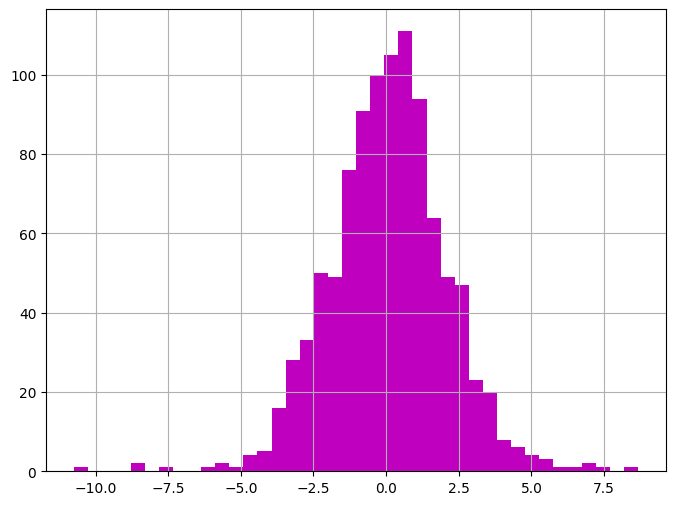

In [42]:
print(h5_values.mean())
print(h5_values.std())
# Find the quantiles
print(np.quantile(h5_values,0.025))
print(np.quantile(h5_values,0.975))
plt.hist(h5_values,bins = 40, color = 'm')
plt.grid()
plt.show()

In [43]:
# 30 day horizon, 1000 simulation points
numSim = 100
numH = 30
forecasts = res.forecast(horizon= numH, method = 'simulation',simulations = numSim) 
hLast_values = forecasts.simulations.values[-1,:,-1] 
hLast_values.shape

(100,)

In [44]:
######################################################################################
#
# Firstly I would like to find the mean of the forecast and the 95% conf interval
# For that, will pick up at the last observation (3149, the h1,...,h100 of each path)
# At every step, I can then get statistics across the paths at every step h1,...,h100 
#
######################################################################################

def plotHorizonForecast(data,tsData,getStats=False):
        #myData = sims.values
      
        numSims = data.shape[0]
        numH = data.shape[1]
          
        path = np.zeros(numSim)
        sizeNumH = numH + 1
        crossSlice = np.zeros((numH+1,numSims))

        mean = np.zeros(numH+1)
        Q95up = np.zeros(numH+1)  #0.975
        Q95down = np.zeros(numH+1) #0.275
        Q80up = np.zeros(numH+1)  #0.90
        Q80down = np.zeros(numH+1) #0.10

        # Add last obs as point 
        lastObsValue = tsData[tsData.index[-1]]
        
        for j in range(numSims): #for each path e  
            crossSlice[0][j] = lastObsValue 

        for j in range(numSims):
            for i in range(numH):
                crossSlice[i+1][j] = data[j][i]

        type(crossSlice)        
        for i in range(1,numH+1):
            mean[i] = stats.describe(crossSlice[i,:]).mean
            Q95up[i] = np.quantile(crossSlice[i,:],0.975)
            Q95down[i] = np.quantile(crossSlice[i,:],0.025)
            Q80up[i] = np.quantile(crossSlice[i,:],0.9)
            Q80down[i] = np.quantile(crossSlice[i,:],0.1)

                 
        plt.figure(1, figsize=(16,16))
        plt.plot(mean, color = 'm', alpha = 1)
        plt.plot(Q95up, color = 'r')
        plt.plot(Q95down, color = 'r')
        plt.plot(Q80up,color = 'g')
        plt.plot(Q80down,color = 'g')
        plt.grid()
        plt.show()
        if(getStats):
            myList = [mean,Q95up,Q95down,Q80up,Q80down]
            myNames= ['mean','Q95up','Q95down','Q80up','Q80down']
            myDict = dict(zip(myNames, myList))
            return myDict

In [45]:
sims = forecasts.simulations
sims.values[-1,:,:].shape
x = sims.values[-1,:,:]

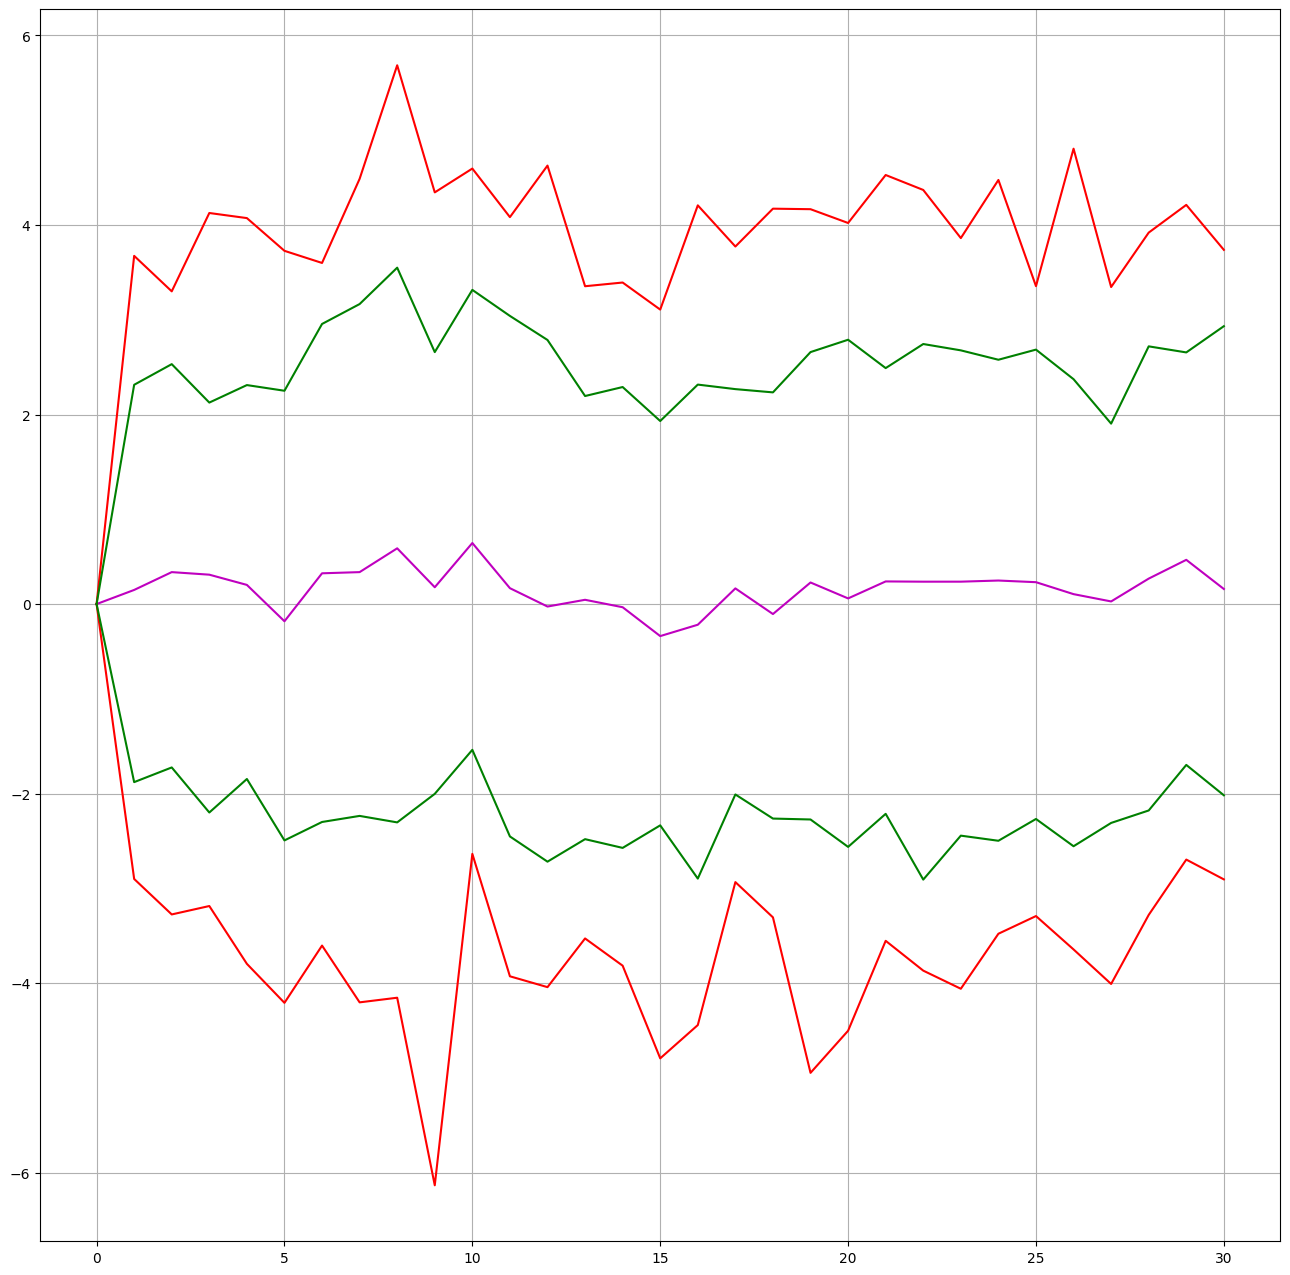

In [46]:
plotHorizonForecast(x,AAPLRet)

In order to be able to forecast with external regressors, we need split the original data for training  
===

- We can use original data and choose to fit the model up to a date, forecasting with the rest or
- We can extend the dataframe with a dummy for the "future dates" and give future values for external regressor

In [47]:
# We will use examples with simulation - for the purpose of this example, we will simply slice the 
# data as the "last_obs" to fit the model and all other points are ignored. Only the dates are 
# used for the future forecasting.
# Quickly figure out 100 days before last obs
AAPLRet.to_frame().shift(-20).tail(21)
#That is 2019-07-09: use this as last_obs as python won't include in the fitting of the model

,Adj Close
Date,
2019-10-29,-0.007839
2019-10-30,NaN
2019-10-31,NaN
2019-11-01,NaN
2019-11-04,NaN
2019-11-05,NaN
2019-11-06,NaN
2019-11-07,NaN
2019-11-08,NaN


In [48]:
split_date = '2019-10-30'
newAAPLRet = AAPLRet*100
arx = ARX(newAAPLRet, lags=4,rescale = False) #this is eq. to AR(4) as per above
arx.volatility = GARCH(5,0,0)
res = arx.fit(update_freq=0, last_obs = split_date)
print(res.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 6440.350251052358
            Iterations: 23
            Function evaluations: 307
            Gradient evaluations: 23
                           AR - ARCH Model Results                            
Dep. Variable:              Adj Close   R-squared:                      -0.003
Mean Model:                        AR   Adj. R-squared:                 -0.004
Vol Model:                       ARCH   Log-Likelihood:               -6440.35
Distribution:                  Normal   AIC:                           12902.7
Method:            Maximum Likelihood   BIC:                           12969.6
                                        No. Observations:                 3224
Date:                Mon, Nov 21 2022   Df Residuals:                     3219
Time:                        12:19:15   Df Model:                            5
                                   Mean Model                                  

In [49]:
numH = 100
forecasts = res.forecast(horizon=numH, method='simulation') #default number of simulations is 1000
sims = forecasts.simulations

In [50]:
sims.values.shape 
# 3228 number of past observations, plus 20 for forecast total of 3248
# Simulated 1000 paths
# Up to 20 days ahead
# Need to extract values of last 20days of paths for histogram

(3248, 1000, 100)

In [51]:
len(AAPLRet[:]) # up to last observation

3248

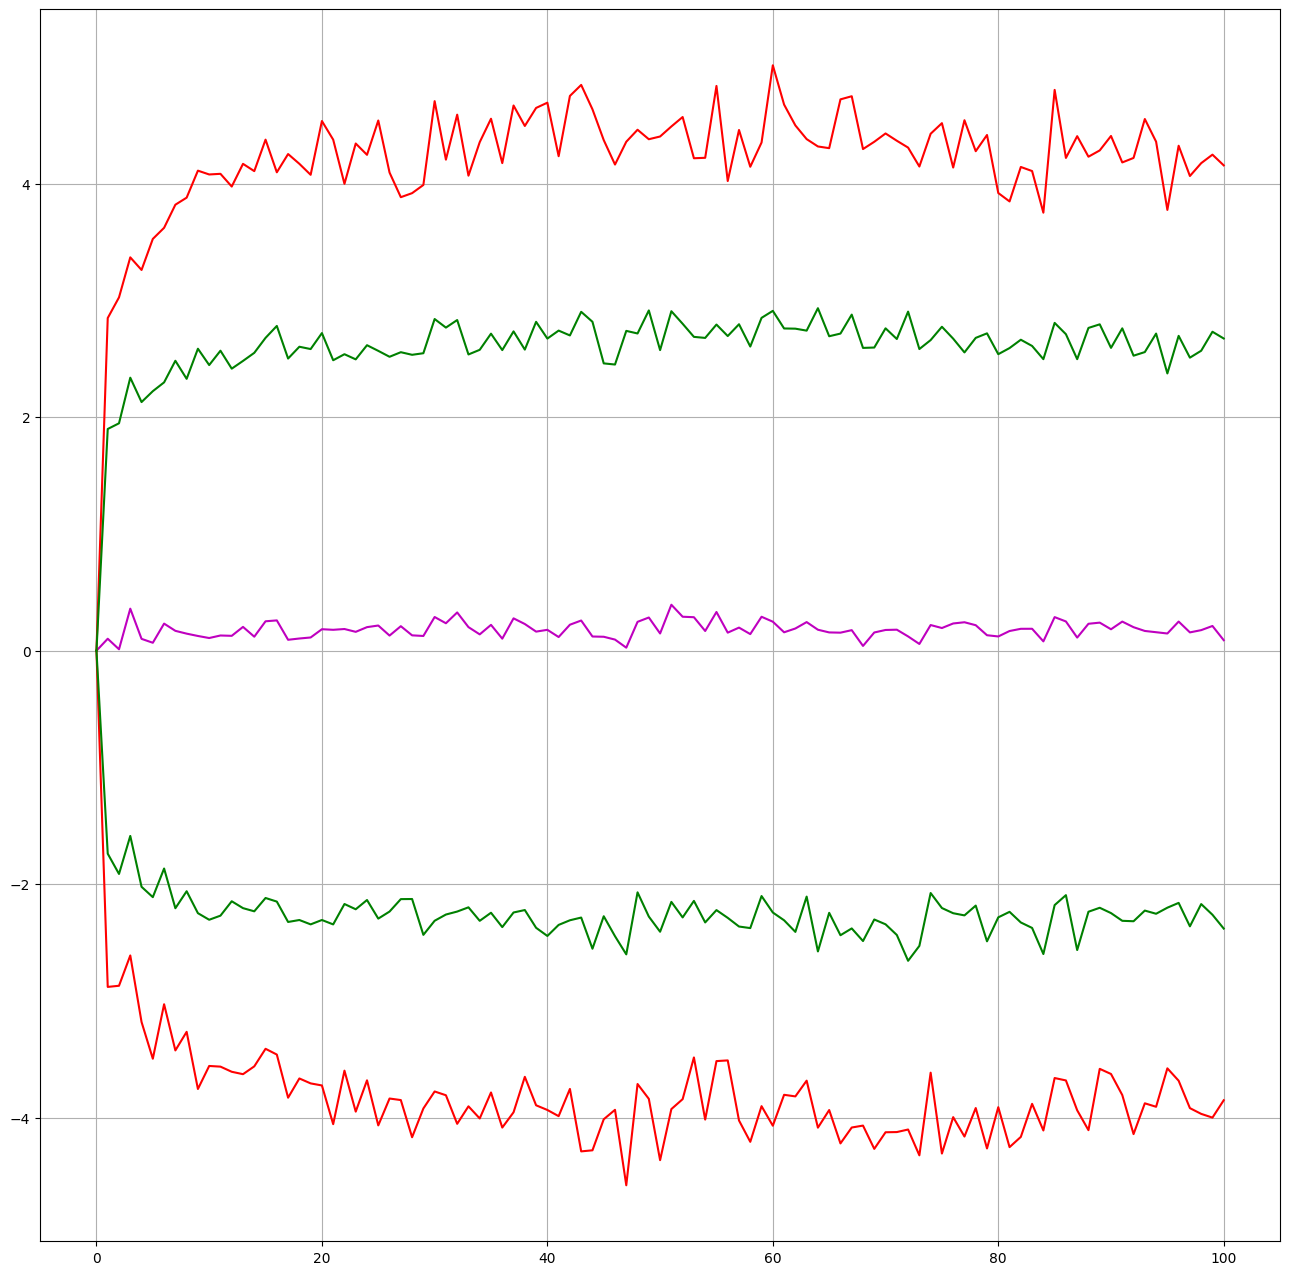

In [52]:
statsRtn = plotHorizonForecast(sims.values[-1,:,:],tsData=AAPLRet, getStats=True)

In [53]:
# Now we cannot have 100 days less
sims.values[-21,-1,0] 


-0.5546682438227638

In [54]:
# Now we cannot have 100 days less
sims.values[-22,-1,0] 


nan

Most importantly:
===
We need to split the data in this way OR add dates up to the horizon we need to forecast
in original time series when we have

External Regressors
===

Whenever we have external regressors, in order to produce forecast, we need to provide the values
of the external forecast in future.

However, if we simply add this data as part of the external regressor but do not align the size
of the timeseries we are trying to fit, the model will not work:

Example to then forecast the actual price given the forecast of the returns
===

In [55]:
prices = AAPL['Adj Close']#AAPL[:'2019-10-29']['Adj Close']
lastPrice = prices[prices.index[-1]]
lastPrice 

64.72974395751953

Remeber that all returns are x by a factor of 100...so we need to divide by 100 to obtain correct units
===

In [56]:
def getPaths(data):
    numSim = data.shape[0]
    numH  = data.shape[1]
    totValueAcrossPath = np.zeros(numSim)
    for j in range(numSim): #for each path    
        for i in range(numH):
            totValueAcrossPath[j] =  totValueAcrossPath[j] + data[j][i]
        
    return totValueAcrossPath

In [57]:
print(sims.values[-1,:,:].shape)#100 day forecast
totReturnPaths = getPaths(sims.values[-1,:,:])
totReturnPaths.shape
# It contains the total path value 

(1000, 100)


(1000,)

totReturnPaths has added all the daily return for the forecast of 100 days ahead, path by path
===

In [58]:
# Now I can exponentite to get back original price
# But remember: you must scale back your returns if you have use this trick...
# And remember to use your initial spot the last spot observation

sizeN = len(totReturnPaths)
spotPrices = np.zeros(sizeN)
for i in range(sizeN):
    spotPrices[i] = np.exp(totReturnPaths[i]/100)*lastPrice


At last... we have the distribution of Spot 100 days ahead 
====

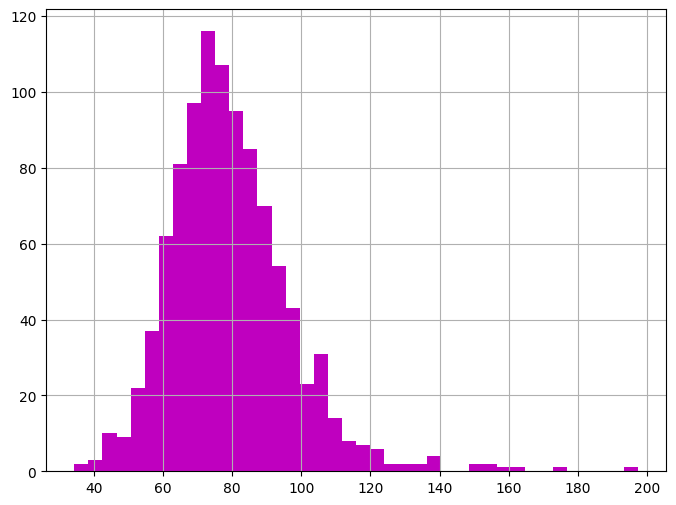

In [59]:
plt.hist(spotPrices, bins = 40, color = 'm')
plt.grid()
plt.show()

And hence we can calculate statistics on it...
===

In [60]:
mean = spotPrices.mean()
std = spotPrices.std()
Quant95up = np.quantile(spotPrices,0.975)
Quant95down = np.quantile(spotPrices,0.0275)
print('Mean: ', mean)
print('Std: ', std)
print('95% Q: ', Quant95up)
print('5% Q: ', Quant95down)

Mean:  79.4599511190769
Std:  17.761218169830702
95% Q:  118.30155766461161
5% Q:  51.68887594088818


How do we set the intervals?
===

- This is more tricky as we need to get the percentiles at every forecasting step h, to obtain the "path for 95%" forecast e.g.

In [61]:
def getPathsExp(forecastSims, lastPrice):
    numSim = forecastSims.shape[0]
    numH = forecastSims.shape[1]
    print(numSim)
    print(numH)
    totValueAcrossPath = np.zeros(numSim)
    spotData = np.zeros((numSim,numH+1))
    for j in range(numSim): #for each path    
        spotData[j,0]=lastPrice
        
    for j in range(numSim): #for each path    
        for i in range(numH):
            spotData[j][i+1] = np.exp(forecastSims[j][i]/100)*spotData[j][i]

    return spotData

In [62]:
print(lastPrice)
spotPaths = getPathsExp(sims.values[-1,:,:],lastPrice)

64.72974395751953
1000
100


In [63]:
spotPaths.T.shape

(101, 1000)

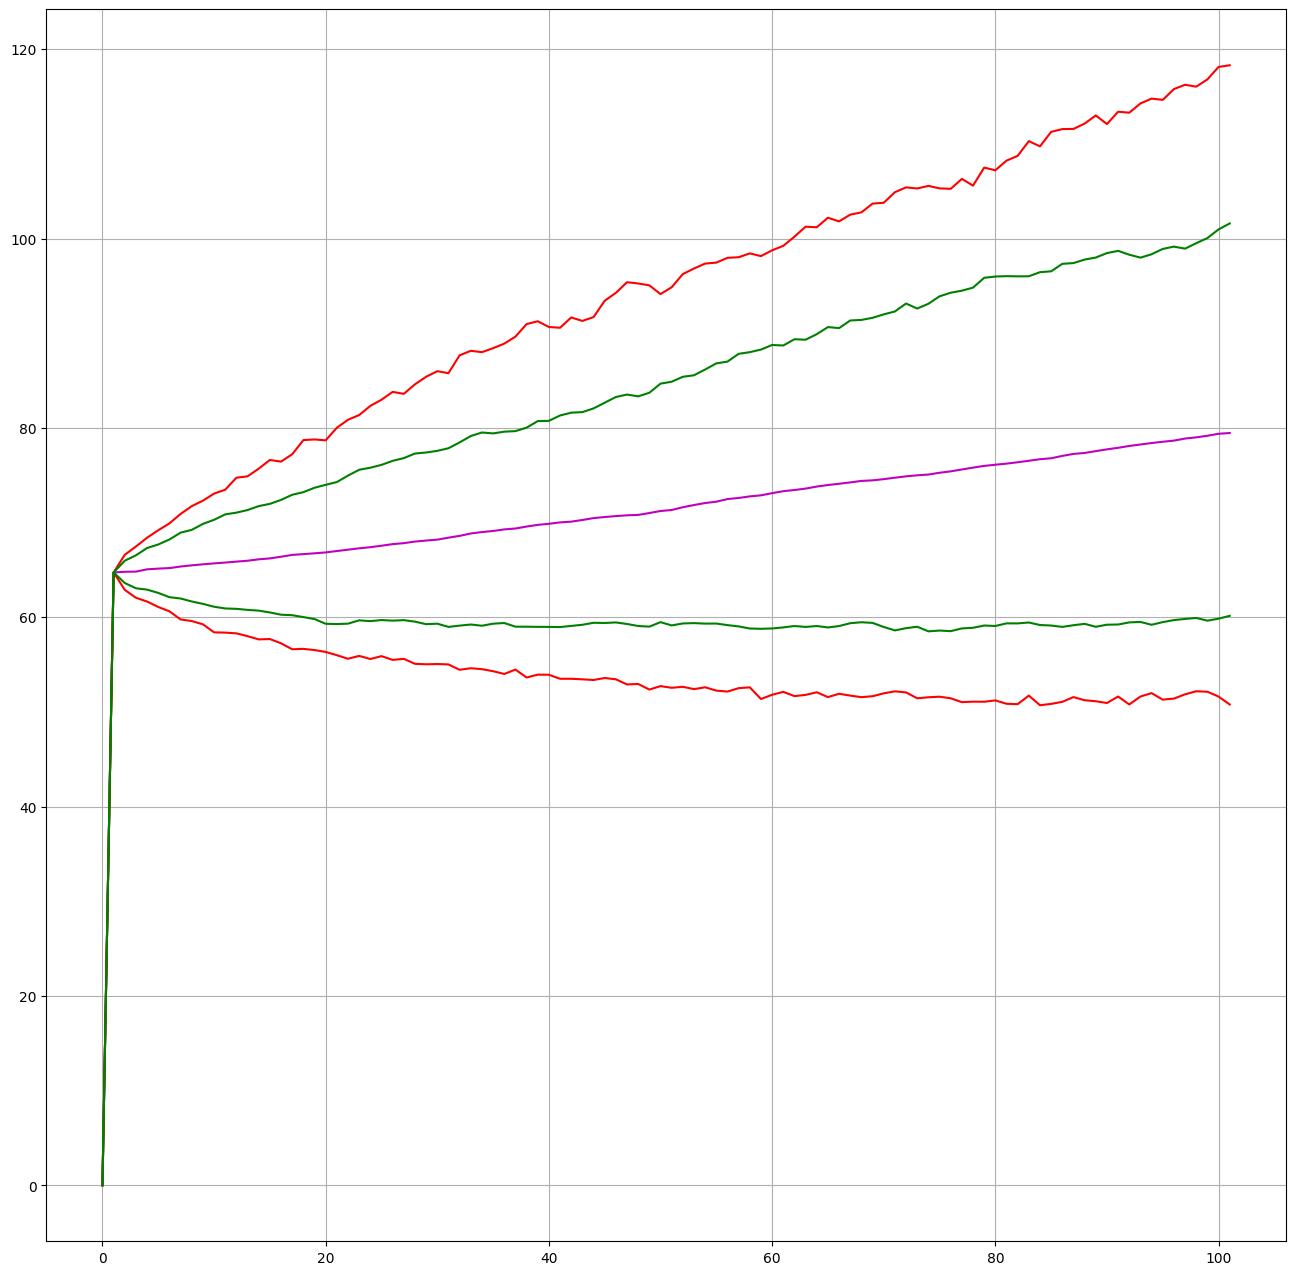

In [64]:
statsData = plotHorizonForecast(spotPaths[:,:],tsData=prices,getStats=True)
meanData = statsData['mean']

In [65]:
sims.values[-1,:,:].shape

(1000, 100)

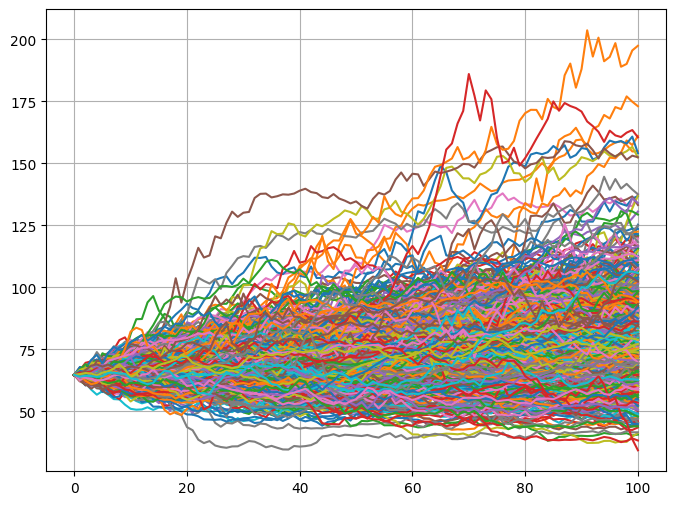

In [66]:
for k in range(1000):
    paths = spotPaths[k,:] 
    plt.plot(paths);

plt.grid()
plt.show()

In [67]:
# Generate new dates for the future...
keep = pd.bdate_range(start='2019-11-27', end='2020-04-14')
len(keep)

myList = [keep.values]
names = ['date']
myDict = dict(zip(names, myList))
df = pd.DataFrame({ key:pd.Series(value) for key, value in myDict.items()})
df.set_index(df['date'], inplace = True)
df.head()
del df['date']

In [68]:
AAPL[:]['Adj Close'].mean()

20.2435051239832

In [69]:
1.4242e-03*100

0.14242

In [70]:
lastPrice*np.exp(0.14242)

74.63733244875358

In [71]:
statsData['mean'][-1]

79.4599511190769